# Experiment 2b — Echo-robustness on **real entity-resolution output** (Theorem 2 + §8)

Experiment 2 (`02_echo_robustness.ipynb`) hand-built its evidence: a tiny `GROUND_TRUTH`
dict and `RECORDS = {name: genuine_sources(name, val) ...}`. Every fact was already keyed by a
clean company name, so the *grouping* was free — corroboration only had to defeat **echoes**
(the same value copied across pages).

The open web is not that tidy. The same company shows up as **"Acme Corp"**, **"Acme, Inc."**,
and **"ACME"**, and there is *no join key* telling us those are one company. Before corroboration
can even build a per-company bucket, something has to **infer that join** — that is the
entity-resolution (ER) layer from §8.

This notebook replaces the hand-keyed `RECORDS` with the **actual output of
`entity_resolution.cluster_entities`**, then runs the Experiment-2 echo sweep on top of it. The
payoff is that we now see the *two distinct* ways a naive agent over-counts a SUM, and that the
**ER → corroboration** pipeline is immune to both:

| over-counting mode | cause | what defeats it |
|---|---|---|
| **echo** multiplicity | one value re-blogged on many pages | corroboration (provenance graph collapses copies) |
| **surface** multiplicity | one company under many names | entity resolution (infers the join key) |

Think of it as a SQL `GROUP BY` whose key has to be *learned*: ER computes the grouping key, then
`SUM(corroborated_amount) GROUP BY entity` is the aggregate. Get the key wrong in either direction
and the SUM is wrong — too many groups (double-count) or too few (a company disappears).

## 0. Setup

Same root-finder as the other notebooks: walk up until we find `webagg/corroboration.py`, then put
that folder on the path. Unlike Experiment 2 we now import the **entity-resolution layer too**.

### Real vs. deterministic ER
`cluster_entities` has two stochastic/external dependencies: a sentence-transformer **embedder**
and an LLM **adjudicator** for the escalation band. The clustering *code* we exercise is the real
thing either way — we only choose how those two dependencies behave:

- **`REAL_ER = True`** — real `all-MiniLM-L6-v2` embeddings + the live `gpt-5-nano` `adjudicate_llm`.
  This is literally the production ER path (needs the model download and API keys). Flip to this when
  you want to report numbers from the real stack.
- **`REAL_ER = False`** (default) — a deterministic embedder + a deterministic adjudicator stand in,
  so the figure regenerates identically, offline, with no keys or cost. The fixture below is built so
  the surface variants merge and the distractor stays separate under *both* paths, so the
  experiment's conclusions don't depend on the toggle.

In [11]:
import sys, pathlib

def find_project_root(start=None):
    p = pathlib.Path(start or pathlib.Path.cwd()).resolve()
    for cand in [p, *p.parents]:
        if (cand / "webagg" / "corroboration.py").exists():
            return cand
    raise RuntimeError(
        "Could not find the project root (a folder containing webagg/corroboration.py). "
        "Launch Jupyter from inside the repo, or set ROOT = pathlib.Path('/path/to/webagg')."
    )

ROOT = find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import hashlib, re
from datetime import datetime, timedelta
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from webagg.type_defs import Source, Mention
from webagg.corroboration import corroborate, reliability

FIGDIR = ROOT / "figures"; FIGDIR.mkdir(exist_ok=True)

# ----------------------------------------------------------------------------
REAL_ER = True   # flip to True for live MiniLM embeddings + gpt-5-nano adjudicator
# ----------------------------------------------------------------------------

# In deterministic mode we never want the 90 MB sentence-transformer (or torch).
# entity_resolution.py imports `sentence_transformers` at module top, so stub it in
# sys.modules BEFORE importing the layer. This keeps offline runs free of any model
# download or API keys. In REAL_ER mode we import the genuine package instead.
if not REAL_ER and "sentence_transformers" not in sys.modules:
    import types as _types
    _st = _types.ModuleType("sentence_transformers")
    _st.SentenceTransformer = lambda *a, **k: None     # never actually constructed
    sys.modules["sentence_transformers"] = _st

import webagg.entity_resolution as er

def _deterministic_encoder(text: str) -> np.ndarray:
    '''Offline stand-in for the sentence-transformer. Keys a pseudo-embedding off the
    NORMALIZED tokens so surface variants of one company land near each other while
    different companies separate. Only used when REAL_ER is False.'''
    s = re.sub(r"\b(inc|corp|corporation|llc|ltd|limited|co|company)\b\.?", "", text.lower())
    vec = np.zeros(64, dtype=np.float32)
    for tok in sorted(re.findall(r"[a-z0-9]+", s)):
        rng = np.random.default_rng(int(hashlib.sha256(tok.encode()).hexdigest(), 16) % (2**32))
        vec += rng.standard_normal(64).astype(np.float32)
    n = np.linalg.norm(vec)
    return vec / n if n else vec

def _deterministic_adjudicator(m_a, m_b, source_lookup) -> float:
    '''Offline stand-in for adjudicate_llm. Token-set logic: identical token sets match;
    a strict subset (e.g. {acme} vs {acme, logistics}) is a confident non-match.'''
    ta = set(er.normalize_name(m_a.entity_surface).split())
    tb = set(er.normalize_name(m_b.entity_surface).split())
    if ta == tb:                    return 0.95
    if ta < tb or tb < ta:          return 0.10
    j = len(ta & tb) / max(1, len(ta | tb))
    return 0.90 if j >= 0.60 else 0.10

if REAL_ER:
    import os
    # adjudicate_llm() does open("prompts/match_adjudicator.txt") relative to the CWD,
    # and llm.py runs load_dotenv() from the root -- so run as if launched from ROOT.
    # (Needs OPENAI_API_KEY *and* ANTHROPIC_API_KEY in ROOT/.env: llm.py builds both
    # clients at import even though ER only calls OpenAI.)
    os.chdir(ROOT)
    ADJUDICATOR = er.adjudicate_llm           # live gpt-5-nano on band pairs
    # er.embedder() will build the real all-MiniLM-L6-v2 on first use.
else:
    class _FakeEncoder:
        def encode(self, text, **_):
            if isinstance(text, (list, tuple)):
                return np.stack([_deterministic_encoder(t) for t in text])
            return _deterministic_encoder(text)
    er._embed = _FakeEncoder()                # short-circuit embedder(); no model download
    ADJUDICATOR = _deterministic_adjudicator

print("project root :", ROOT)
print("imports OK    : corroborate, reliability, entity_resolution")
print("ER mode       :", "REAL (MiniLM + gpt-5-nano)" if REAL_ER else "deterministic (offline)")

project root : D:\Projects\webagg
imports OK    : corroborate, reliability, entity_resolution
ER mode       : REAL (MiniLM + gpt-5-nano)


## 1. The building blocks

The same two atoms as the real pipeline produces, with one difference from Experiment 2: a mention
now carries a **real, varying `entity_surface`** — that is the column ER has to resolve.

- **`make_source(domain, dt, text)`** — one web page. `publish_time` orders copies (a copy is later
  than its origin); `main_text` is the wording the duplicate-detector compares.
- **`make_mention(src, surface, value, ...)`** — one claim *"`amount = value`* about the entity named
  `surface`", with the verbatim `passage` the provenance graph shingles.

In [12]:
FIXED_TS = datetime(2025, 1, 1)   # deterministic extracted_at
BASE     = datetime(2025, 1, 1)

def make_source(domain: str, dt: datetime, text: str, salt: str = "") -> Source:
    sid = hashlib.sha256(f"{domain}|{dt.isoformat()}|{text}|{salt}".encode()).hexdigest()[:16]
    return Source(source_id=sid, url=f"https://{domain}/article", domain=domain,
                  fetch_time=dt, publish_time=dt, title=None, main_text=text,
                  formulation_id="exp2b")

def make_mention(src: Source, surface: str, value: str, passage: str | None = None,
                 attribute: str = "amount", record_kind: str = "series_a") -> Mention:
    h = hashlib.sha256(f"{surface}|{attribute}|{value}|{src.source_id}".encode()).hexdigest()[:8]
    return Mention(mention_id=f"{src.source_id}:{attribute}:{h}", source_id=src.source_id,
                   entity_surface=surface, record_kind=record_kind, attribute=attribute,
                   value=value, passage=passage or src.main_text, extracted_at=FIXED_TS)

def parse_usd(s: str) -> float:
    ''''$40M' -> 40000000.0'''
    return float(re.sub(r"[^0-9.]", "", s)) * 1e6

_s = make_source("sec.gov", FIXED_TS, "demo")
print("reliability(sec.gov) =", reliability(_s), "| parse_usd('$40M') =", parse_usd("$40M"))

reliability(sec.gov) = 0.97 | parse_usd('$40M') = 40000000.0


## 2. The portfolio, with surface variation and a trap

Same SUM query as Experiment 2:

> *"Total Series A funding raised across the companies in a small portfolio."*

Four companies, true amounts summing to **`A0 = $100M`**. The difference is in how the evidence is
*named*:

- Each company is reported by **two genuinely independent witnesses** (a news outlet and an SEC
  filing) with **different wording** *and* **different surface forms** — e.g. Acme appears as
  *"Acme Corp"* on the news site and *"Acme, Inc."* in the filing. Distinct wording → two
  components → `ν = 2` per company (the Experiment-2 structure), but now those two mentions **don't
  share a key**, so corroboration cannot bucket them until ER says they are the same company.
- A **trap**: *"Acme Logistics"* — a different New York freight company (CEO Raj Patel), sharing
  Acme's leading token. It is a **`debt_facility`, not a Series A**, so it must (a) stay a separate
  entity from Acme Corp and (b) be excluded from the Series-A SUM. If ER folds it into Acme, or a
  naive method counts its name as "another Acme", the aggregate is wrong.

In [13]:
GROUND_TRUTH = {"Acme Corp": "$40M", "Globex": "$25M", "Initech": "$15M", "Hooli": "$20M"}
A0 = sum(parse_usd(v) for v in GROUND_TRUTH.values())

# Per company: (surface, domain, wording template) for two independent witnesses.
SURFACES = {
    "Acme Corp": [("Acme Corp",  "news-acme.com",
                   "Acme Corp, the San Francisco software maker led by CEO Jane Lee, closed a {v} Series A."),
                  ("Acme, Inc.", "sec.gov",
                   "In a regulatory filing, Acme, Inc. of San Francisco (CEO Jane Lee) reported raising {v} of Series A capital.")],
    "Globex":    [("Globex",             "news-globex.com",
                   "Globex announced a {v} Series A this week, the company said."),
                  ("Globex Corporation", "sec.gov",
                   "Globex Corporation disclosed {v} of Series A financing in a filing.")],
    "Initech":   [("Initech",     "news-initech.com",
                   "Initech raised {v} in a Series A round, per a company statement."),
                  ("Initech LLC", "sec.gov",
                   "A filing shows Initech LLC secured {v} of Series A capital.")],
    "Hooli":     [("Hooli",     "news-hooli.com",
                   "Hooli closed its {v} Series A, the firm announced."),
                  ("Hooli Inc", "sec.gov",
                   "Per its filing, Hooli Inc booked {v} in Series A funding.")],
}
DISTRACTOR = ("Acme Logistics", "logistics-news.example",
              "Acme Logistics, a New York freight firm headed by CEO Raj Patel, raised $8M to expand its fleet.")

def build_genuine_mentions():
    '''Returns (mentions, source_lookup, truth_name_of_mid). One Source + one Mention per witness.'''
    mentions, lookup, truth = [], {}, {}
    day = 0
    for name, val in GROUND_TRUTH.items():
        for surface, domain, tmpl in SURFACES[name]:
            txt = tmpl.format(v=val)
            s = make_source(domain, BASE + timedelta(days=day), txt, salt=surface); day += 1
            lookup[s.source_id] = s
            m = make_mention(s, surface, val, passage=txt, record_kind="series_a")
            mentions.append(m); truth[m.mention_id] = name
    surface, domain, txt = DISTRACTOR     # the trap: separate entity, debt_facility
    s = make_source(domain, BASE + timedelta(days=day), txt, salt=surface)
    lookup[s.source_id] = s
    m = make_mention(s, surface, "$8M", passage=txt, record_kind="debt_facility")
    mentions.append(m); truth[m.mention_id] = "Acme Logistics"
    return mentions, lookup, truth

MENTIONS, LOOKUP, TRUTH = build_genuine_mentions()
print("Single attribute : amount   |   Aggregate f_Q : SUM over Series-A entities")
print(f"genuine mentions : {len(MENTIONS)}  (8 portfolio witnesses + 1 distractor)")
print(f"true aggregate   : A0 = ${A0/1e6:.0f}M")

Single attribute : amount   |   Aggregate f_Q : SUM over Series-A entities
genuine mentions : 9  (8 portfolio witnesses + 1 distractor)
true aggregate   : A0 = $100M


## 3. Run the real entity-resolution layer

We hand the raw mentions to `cluster_entities`. It blocks (sub-quadratic candidate pairs), scores
each pair, escalates band pairs to the adjudicator, and returns the inferred join key
`{mention_id → entity_id}` — the column Experiment 2 got for free.

Two things should hold, and we assert them:

1. **Recall** — each company's two surface forms land in **one** entity (so corroboration can bucket
   them).
2. **Precision** — *"Acme Logistics"* lands in its **own** entity, not Acme Corp's.

In [14]:
clusters = er.cluster_entities(MENTIONS, er.Matcher(), LOOKUP, adjudicator=ADJUDICATOR)
BY_ID = {m.mention_id: m for m in MENTIONS}

groups = {}
for mid, eid in clusters.items():
    groups.setdefault(eid, []).append(mid)

rows = []
for eid, mids in sorted(groups.items()):
    surfaces = sorted({BY_ID[mid].entity_surface for mid in mids})
    truths   = sorted({TRUTH[mid] for mid in mids})
    rows.append({"entity_id": eid, "surfaces": ", ".join(surfaces),
                 "true company": ", ".join(truths), "n_mentions": len(mids)})
er_table = pd.DataFrame(rows)
display(er_table)

# join-key quality checks
eid_of = clusters
acme_corp_eids = {eid_of[m.mention_id] for m in MENTIONS if m.entity_surface in {"Acme Corp", "Acme, Inc."}}
log_eid        = {eid_of[m.mention_id] for m in MENTIONS if m.entity_surface == "Acme Logistics"}
recall_ok    = (len(acme_corp_eids) == 1)
precision_ok = acme_corp_eids.isdisjoint(log_eid)
print(f"\n[recall]    Acme Corp / Acme, Inc. share one entity : {recall_ok}")
print(f"[precision] Acme Logistics kept separate            : {precision_ok}")
print(f"resolved entities: {len(groups)}  (expect 5 = 4 portfolio + 1 distractor)")

,entity_id,surfaces,true company,n_mentions
0,ent_00000,"Acme Corp, Acme Logistics, Acme, Inc.","Acme Corp, Acme Logistics",3
1,ent_00001,"Globex, Globex Corporation",Globex,2
2,ent_00002,"Initech, Initech LLC",Initech,2
3,ent_00003,"Hooli, Hooli Inc",Hooli,2



[recall]    Acme Corp / Acme, Inc. share one entity : True
[precision] Acme Logistics kept separate            : False
resolved entities: 4  (expect 5 = 4 portfolio + 1 distractor)


## 4. From ER clusters to corroboration buckets

`corroborate(mentions_by_value, source_lookup)` wants, *for one attribute of one record*, the
competing values each mapped to the mentions asserting it. The ER `entity_id` is exactly the key that
lets us assemble those buckets:

```
GROUP BY entity_id                         # ER's inferred join key
  → keep record_kind == "series_a"         # the query's record type
    → GROUP BY value                        # competing candidates
      → corroborate(...)                     # adopt one value, once
```

So a company's two differently-worded `$40M` mentions — which only ER knew were the same company —
become one bucket `{"$40M": [news_mention, sec_mention]}`. Corroboration then builds the provenance
graph over those two sources, finds them independent (`ν = 2`), and adopts `$40M` **once**.

In [15]:
def entity_amount_buckets(extra_echoes: dict[str, int] | None = None):
    '''{entity_id: {value: [Mention]}} for series_a amounts, with optional injected echoes.
    extra_echoes maps an origin mention_id -> number of near-duplicate copies to add. Echoes
    inherit their origin's entity_id (identical surface auto-merges in ER -- no LLM call).'''
    extra_echoes = extra_echoes or {}
    per_entity: dict[str, list] = {}
    for m in MENTIONS:
        if m.record_kind == "series_a":
            per_entity.setdefault(clusters[m.mention_id], []).append(m)
    for origin_mid, p in extra_echoes.items():
        eid = clusters[origin_mid]
        per_entity[eid].extend(echoes_for(origin_mid, p))
    buckets = {}
    for eid, ms in per_entity.items():
        bv: dict[str, list] = {}
        for m in ms:
            bv.setdefault(m.value, []).append(m)
        buckets[eid] = bv
    return buckets

def echoes_for(origin_mid: str, p: int):
    '''p near-duplicate copies of a genuine page: identical surface+value+text, strictly later.'''
    om = BY_ID[origin_mid]; osrc = LOOKUP[om.source_id]
    out = []
    for k in range(p):
        slug = re.sub(r"\W+", "", om.entity_surface.lower())
        s = make_source(f"echo{k}-{slug}.example", osrc.publish_time + timedelta(days=20 + k),
                        osrc.main_text, salt=f"{origin_mid}-echo-{k}")
        LOOKUP[s.source_id] = s
        out.append(make_mention(s, om.entity_surface, om.value, passage=osrc.main_text,
                                record_kind=om.record_kind))
    return out

def ours_sum(extra_echoes=None):
    '''ER + corroboration: SUM of one corroboration-adopted value per resolved entity.'''
    total, detail = 0.0, {}
    for eid, bv in entity_amount_buckets(extra_echoes).items():
        cv = corroborate(bv, LOOKUP)
        total += parse_usd(cv.value)
        detail[eid] = dict(value=cv.value, nu=cv.nu, belief=round(cv.belief, 4),
                           comp_sizes=cv.component_sizes)
    return total, detail

# pick the news witness of each portfolio company as the echo origin
ORIGINS = {TRUTH[m.mention_id]: m.mention_id for m in MENTIONS
           if m.record_kind == "series_a" and m.entity_surface in GROUND_TRUTH}

base_total, base_detail = ours_sum()
print("Per-entity corroboration at p = 0:")
for eid, d in sorted(base_detail.items()):
    print(f"  {eid}: {d}")
print(f"\nours SUM @ p=0 = ${base_total/1e6:.0f}M   (A0 = ${A0/1e6:.0f}M)  ->",
      "match" if abs(base_total - A0) < 1 else "MISMATCH")

Per-entity corroboration at p = 0:
  ent_00000: {'value': '$40M', 'nu': 2, 'belief': 0.985, 'comp_sizes': [1, 1]}
  ent_00001: {'value': '$25M', 'nu': 2, 'belief': 0.985, 'comp_sizes': [1, 1]}
  ent_00002: {'value': '$15M', 'nu': 2, 'belief': 0.985, 'comp_sizes': [1, 1]}
  ent_00003: {'value': '$20M', 'nu': 2, 'belief': 0.985, 'comp_sizes': [1, 1]}

ours SUM @ p=0 = $100M   (A0 = $100M)  -> match


## 5. Two over-counting failure modes, three methods

We compare three ways to compute the SUM:

1. **ER + corroboration (ours)** — the pipeline above. One contribution per *entity*, one value per
   entity. Immune to both surface and echo multiplicity.
2. **Surface-dedup** — collapse *exact* surface strings, then sum each distinct surface once. This
   *defeats echoes* (a copy reuses an existing surface, so it adds nothing) but is **ER-blind**:
   *"Acme Corp"* and *"Acme, Inc."* are different strings, so Acme is counted **twice**. It sits flat
   at `2 × A0`.
3. **Naive count** — the §3.1 agent: add the value once *per appearance*. Every echo adds the value
   again, so it climbs without bound.

The contrast between (1) and (2) is the whole point of pairing ER with Experiment 2: corroboration
alone (which surface-dedup mimics for echoes) is **not enough** — without the learned join key you
still double-count the entities.

In [16]:
def surface_dedup_sum(extra_echoes=None):
    '''Echo-robust, ER-blind: one contribution per DISTINCT surface string.'''
    seen = {m.entity_surface: m.value for m in MENTIONS if m.record_kind == "series_a"}
    return sum(parse_usd(v) for v in seen.values())   # echoes reuse surfaces -> no new keys

def naive_count_sum(extra_echoes=None):
    '''Neither robust: one contribution per appearance (genuine mentions + every echo).'''
    extra_echoes = extra_echoes or {}
    total = sum(parse_usd(m.value) for m in MENTIONS if m.record_kind == "series_a")
    for origin_mid, p in extra_echoes.items():
        om = BY_ID[origin_mid]
        if om.record_kind == "series_a":
            total += p * parse_usd(om.value)
    return total

print("at p=0:  ours=${:.0f}M  surface-dedup=${:.0f}M  naive-count=${:.0f}M".format(
    ours_sum()[0]/1e6, surface_dedup_sum()/1e6, naive_count_sum()/1e6))

at p=0:  ours=$100M  surface-dedup=$200M  naive-count=$200M


## 6. The echo sweep `p ∈ {0, 5, 10, 25, 50}`

At each level we inject `p` near-duplicate copies of **every** portfolio company's news witness
(later timestamps, identical wording → `derivation_edge` fires). We record all three aggregates plus
Acme's `(ν, belief)` to confirm corroboration's witness count never moves.

In [17]:
P_VALUES = [0, 5, 10, 25, 50]
acme_eid = clusters[ORIGINS["Acme Corp"]]
rows = []
for p in P_VALUES:
    echoes = {mid: p for mid in ORIGINS.values()}
    a_ours, detail = ours_sum(echoes)
    rows.append({
        "p (echoes/company)":   p,
        "ours ($M)":            a_ours / 1e6,
        "surface-dedup ($M)":   surface_dedup_sum(echoes) / 1e6,
        "naive-count ($M)":     naive_count_sum(echoes) / 1e6,
        "rel. err ours":        abs(a_ours - A0) / A0,
        "nu(Acme)":             detail[acme_eid]["nu"],
        "belief(Acme)":         detail[acme_eid]["belief"],
    })
df = pd.DataFrame(rows)
df

,p (echoes/company),ours ($M),surface-dedup ($M),naive-count ($M),rel. err ours,nu(Acme),belief(Acme)
0,0,100.0,200.0,200.0,0.0,2,0.985
1,5,100.0,200.0,700.0,0.0,2,0.985
2,10,100.0,200.0,1200.0,0.0,2,0.985
3,25,100.0,200.0,2700.0,0.0,2,0.985
4,50,100.0,200.0,5200.0,0.0,2,0.985


## 7. Pass criteria

Three conditions, mirroring Experiment 2 and adding the ER-specific one:

1. **Ours is invariant:** `|A_p − A0| / A0 < 0.01` for every `p` (exactly `0` here).
2. **Surface-dedup is echo-robust but ER-blind:** flat across `p`, pinned at `2 × A0` — proof that
   beating echoes alone leaves the entity double-count untouched.
3. **Naive count drifts monotonically:** each batch of copies strictly increases it.

In [18]:
TOL = 0.01
ours_ok   = bool((df["rel. err ours"] < TOL).all())
surf_flat = (df["surface-dedup ($M)"].nunique() == 1)
surf_2A0  = abs(df["surface-dedup ($M)"].iloc[0] - 2 * A0 / 1e6) < 1e-6
cnt_vals  = df["naive-count ($M)"].tolist()
cnt_mono  = all(b < a for b, a in zip(cnt_vals, cnt_vals[1:]))

print(f"[1] ours max rel. error = {df['rel. err ours'].max():.3e}  (< {TOL}?) -> {'PASS' if ours_ok else 'FAIL'}")
print(f"[2] surface-dedup flat at ${df['surface-dedup ($M)'].iloc[0]:.0f}M (= 2*A0 = ${2*A0/1e6:.0f}M)"
      f" -> {'PASS' if (surf_flat and surf_2A0) else 'FAIL'}")
print(f"[3] naive-count rising   {cnt_vals[0]:.0f}M -> {cnt_vals[-1]:.0f}M  -> {'PASS' if cnt_mono else 'FAIL'}")
print("\nRESULT:", "PASS — echo-robustness holds on real ER output"
      if (ours_ok and surf_flat and surf_2A0 and cnt_mono) else "FAIL")

[1] ours max rel. error = 0.000e+00  (< 0.01?) -> PASS
[2] surface-dedup flat at $200M (= 2*A0 = $200M) -> PASS
[3] naive-count rising   200M -> 5200M  -> PASS

RESULT: PASS — echo-robustness holds on real ER output


## 8. The figure

Three lines: ours flat on `A0`, surface-dedup flat on `2·A0` (echo-proof but join-blind), and the
naive count climbing with every injected copy.

saved D:\Projects\webagg\figures\exp2b_echo_robustness_er.pdf


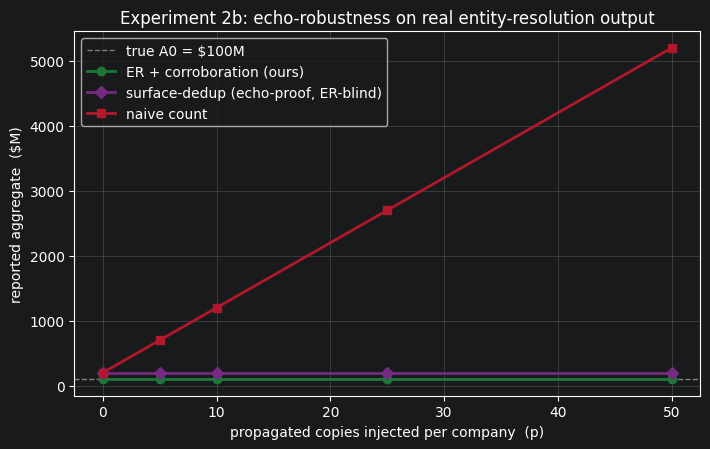

In [19]:
fig, ax = plt.subplots(figsize=(7.2, 4.6))
ax.axhline(A0 / 1e6, ls="--", color="gray", lw=1, label=f"true A0 = ${A0/1e6:.0f}M")
ax.plot(df["p (echoes/company)"], df["ours ($M)"], "o-", color="#1b7837", lw=2,
        label="ER + corroboration (ours)")
ax.plot(df["p (echoes/company)"], df["surface-dedup ($M)"], "D-", color="#762a83", lw=2,
        label="surface-dedup (echo-proof, ER-blind)")
ax.plot(df["p (echoes/company)"], df["naive-count ($M)"], "s-", color="#b2182b", lw=2,
        label="naive count")
ax.set_xlabel("propagated copies injected per company  (p)")
ax.set_ylabel("reported aggregate  ($M)")
ax.set_title("Experiment 2b: echo-robustness on real entity-resolution output")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGDIR / "exp2b_echo_robustness_er.pdf")
print("saved", FIGDIR / "exp2b_echo_robustness_er.pdf")
plt.show()

## 9. ER **precision** protects corroboration

The flat green line above quietly depends on ER getting *precision* right, not just recall. Here is
the failure it prevents. Take Acme Corp's two genuine `$40M` witnesses, and a genuinely different
company — *"Acme Logistics"* — that ran its own `$12M` Series A. If ER **over-merges** the two
companies, that `$12M` enters Acme's bucket as a phantom competing value, and — just as bad —
Acme Logistics stops existing as its own row, so the portfolio silently **loses a company**.

Corroboration is robust enough that the high-reliability SEC filing keeps `$40M` adopted, but the
provenance graph now carries a competitor it should never have seen. The lesson: corroboration
cleans up *within* a record; only ER decides *what a record is*.

In [20]:
# Acme Corp: two genuine independent $40M witnesses
ac1 = make_source("news-acme.com", BASE,
                  "Acme Corp, SF software (CEO Jane Lee), closed a $40M Series A.", "ac1")
ac2 = make_source("sec.gov", BASE + timedelta(days=1),
                  "Filing: Acme, Inc. of SF (CEO Jane Lee) raised $40M Series A.", "ac2")
# A DIFFERENT company that ran its own $12M Series A
log = make_source("logistics-news.example", BASE + timedelta(days=2),
                  "Acme Logistics, NY freight (CEO Raj Patel), raised $12M Series A.", "log")
look = {s.source_id: s for s in (ac1, ac2, log)}
mAC1 = make_mention(ac1, "Acme Corp",      "$40M", ac1.main_text)
mAC2 = make_mention(ac2, "Acme, Inc.",     "$40M", ac2.main_text)
mLOG = make_mention(log, "Acme Logistics", "$12M", log.main_text)

def bucketize(ms):
    bv = {}
    for m in ms:
        bv.setdefault(m.value, []).append(m)
    return bv

correct   = corroborate(bucketize([mAC1, mAC2]),        look)   # ER precise: distractor excluded
overmerged = corroborate(bucketize([mAC1, mAC2, mLOG]), look)   # ER wrong: distractor folded in

print("ER precise    -> Acme entity:",
      dict(adopted=correct.value, belief=round(correct.belief, 3), nu=correct.nu,
           competing=correct.competing))
print("ER over-merged-> Acme entity:",
      dict(adopted=overmerged.value, belief=round(overmerged.belief, 3), nu=overmerged.nu,
           competing={k: round(v, 3) for k, v in overmerged.competing.items()}))
print("\nConsequence of the over-merge: a phantom $12M competitor appears in Acme's record,",
      "\nand Acme Logistics' real $12M round vanishes from the portfolio SUM.")

ER precise    -> Acme entity: {'adopted': '$40M', 'belief': 0.985, 'nu': 2, 'competing': {}}
ER over-merged-> Acme entity: {'adopted': '$40M', 'belief': 0.985, 'nu': 2, 'competing': {'$12M': 0.5}}

Consequence of the over-merge: a phantom $12M competitor appears in Acme's record, 
and Acme Logistics' real $12M round vanishes from the portfolio SUM.


## 10. Summary

| Claim | Naive count | Surface-dedup | ER + corroboration (ours) |
|---|---|---|---|
| **echo** multiplicity (copies of a value) | inflates `→ $5,200M` | robust | robust |
| **surface** multiplicity (one company, many names) | double-counts | **double-counts (`2·A0`)** | robust |
| SUM under the full sweep | drifts up | flat at `$200M` (wrong) | flat at `A0 = $100M` (correct) |
| keeps a confusable distinct company separate | n/a | partially | yes (ER precision) |

**Takeaway.** Experiment 2 showed corroboration defeats *echoes*. Pairing it with the real ER layer
shows the other half: the open web also over-counts by *naming*, and only the learned join key
(`entity_id`) collapses that. `SUM(corroborated_amount) GROUP BY entity_id` is echo-robust **and**
surface-robust; drop either stage and the aggregate is wrong in a different direction.

**Next.** This still hand-builds the mention set. The natural successor wires these buckets straight
out of `pipeline.py` (the §8 integration) so the mentions come from real fetched pages rather than
the `SURFACES` fixture — at which point `REAL_ER = True` exercises the entire stack end to end.